<a href="https://colab.research.google.com/github/LiQuinChing/DL-fakeNewsClassification/blob/Vihara-LSTM/LSTMround2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
# Remove any existing contents in the mount directory
if os.path.exists('/content/drive'):
  !rm -rf /content/drive/*
drive.mount('/content/drive')

Mounted at /content/drive


Install KerasTuner (once per runtime)

In [2]:
!pip -q install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.4 MB/s eta 0:00:00


Hyperparameter search + final fit + save + evaluate

In [3]:
# ============================================
# KerasTuner BiLSTM (2nd round, fine-tuned)
# ============================================
import os, re, json, numpy as np, pandas as pd
from glob import glob

# ---------- Paths ----------
BASE = "/content/drive/MyDrive"
DATA_ROOT = f"{BASE}/news_clean1"     # <— your cleaned data root
ART_DIR   = f"{BASE}/news_models_tuned"   # artifacts for this round
SPLIT_DIR = f"{BASE}/news_splits_tuned"   # splits for this round
os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

# ---------- Load ALL cleaned csvs ----------
paths_fnr = sorted(glob(os.path.join(DATA_ROOT, "fake_and_real", "**", "*.csv"), recursive=True))
paths_fake_mixed = sorted(glob(os.path.join(DATA_ROOT, "fake", "**", "*.csv"), recursive=True))
paths_real_only  = sorted(glob(os.path.join(DATA_ROOT, "real", "archive", "*.csv")))

def safe_read(path):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print("skip (read error):", path, e)
        return None
    cols = [c.lower().strip() for c in df.columns]
    df.columns = cols
    keep = [c for c in ["title","text","label"] if c in df.columns]
    if not keep:
        print("skip (no expected columns):", path)
        return None
    df = df[keep].copy()
    if "title" not in df.columns: df["title"] = ""
    def clean_ws(s):
        if pd.isna(s): return ""
        s = str(s).replace("\u201c",'"').replace("\u201d",'"').replace("\u2019","'")
        return re.sub(r"\s+", " ", s).strip()
    df["title"] = df["title"].map(clean_ws)
    df["text"]  = df["text"].map(clean_ws)
    return df

dfs = []
for p in paths_fnr + paths_fake_mixed + paths_real_only:
    df = safe_read(p)
    if df is None: continue
    if "label" not in df.columns:
        # infer if missing: under real-only → 1; under fake branch → 0; fallback by filename
        rp = p.replace("\\","/").lower()
        if "/real/" in rp: df["label"] = 1
        elif "/fake/" in rp: df["label"] = 0
        else:
            name = os.path.basename(p).lower()
            df["label"] = 1 if ("real" in name or "true" in name) else 0
    dfs.append(df)

assert len(dfs) > 0, "No data loaded—check DATA_ROOT."

data = pd.concat(dfs, ignore_index=True)

# map labels robustly to 0/1
def to01(x):
    x = str(x).strip().lower()
    if x in ["1","real","true","yes","y"]: return 1
    if x in ["0","fake","false","no","n"]: return 0
    try:
        return 1 if float(x) >= 0.5 else 0
    except:
        return np.nan
data["label"] = data["label"].map(to01)
data = data.dropna(subset=["text","label"]).copy()
data["label"] = data["label"].astype(int)

# concat title → text for a small lift
data["text_full"] = np.where(
    data["title"].fillna("").str.len() > 0,
    data["title"].fillna("") + " . " + data["text"].fillna(""),
    data["text"].fillna("")
)

# prune empties/dupes
data = data[data["text_full"].str.len() >= 10].copy()
data = data.drop_duplicates(subset=["text_full"]).reset_index(drop=True)

print("Rows:", len(data), "| Positives (real=1):", int((data["label"]==1).sum()))

# ---------- Splits ----------
from sklearn.model_selection import train_test_split
X_train_texts, X_tmp, y_train, y_tmp = train_test_split(
    data["text_full"].values, data["label"].values,
    test_size=0.2, random_state=42, stratify=data["label"].values
)
X_val_texts, X_test_texts, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

# Save exact splits (raw text); helpful for reproducibility
pd.DataFrame({"text_full": X_train_texts, "label": y_train}).to_csv(os.path.join(SPLIT_DIR,"train.csv"), index=False)
pd.DataFrame({"text_full": X_val_texts,   "label": y_val  }).to_csv(os.path.join(SPLIT_DIR,"val.csv"),   index=False)
pd.DataFrame({"text_full": X_test_texts,  "label": y_test }).to_csv(os.path.join(SPLIT_DIR,"test.csv"),  index=False)

# ---------- Class weights ----------
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0,1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print("Class weight:", class_weight)

# ---------- Tuner (on raw strings via TextVectorization) ----------
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import keras_tuner as kt

# tf.data for speed
BATCH = 128
train_ds_raw = tf.data.Dataset.from_tensor_slices((X_train_texts, y_train)).shuffle(8192).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds_raw   = tf.data.Dataset.from_tensor_slices((X_val_texts,   y_val)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds_raw  = tf.data.Dataset.from_tensor_slices((X_test_texts,  y_test)).batch(BATCH)

def custom_standardize(x):
    # lower + strip HTML-ish tags + collapse spaces; keep punctuation (useful for news)
    x = tf.strings.lower(x)
    x = tf.strings.regex_replace(x, r"<[^>]+>", " ")
    x = tf.strings.regex_replace(x, r"\s+", " ")
    return x

def model_builder(hp: kt.HyperParameters):
    max_tokens = hp.Choice("max_tokens", [40000, 60000, 80000, 100000])
    seq_len    = hp.Choice("seq_len",    [300, 400, 512, 600])
    emb_dim    = hp.Choice("emb_dim",    [128, 192, 256])
    lstm_units = hp.Choice("lstm_units", [64, 96, 128])
    dense_units= hp.Choice("dense_units",[128, 192, 256])
    dropout    = hp.Choice("dropout",    [0.2, 0.3, 0.4, 0.5])
    lr         = hp.Choice("lr",         [1e-3, 2e-3, 3e-3, 5e-4])

    # raw string input
    text_in = layers.Input(shape=(), dtype=tf.string, name="text")
    # vectorizer (adapted on-the-fly to X_train_texts)
    vectorize = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=seq_len,
        standardize=custom_standardize,
        name="tv"
    )
    # adapt inside builder to ensure each trial uses its own config
    vectorize.adapt(tf.data.Dataset.from_tensor_slices(X_train_texts).batch(1024))

    x = vectorize(text_in)
    x = layers.Embedding(input_dim=max_tokens, output_dim=emb_dim, name="emb")(x)
    x = layers.SpatialDropout1D(dropout)(x)
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True))(x)
    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([x_avg, x_max])
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-6))(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=text_in, outputs=out)
    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    model.compile(optimizer=opt, loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.BinaryAccuracy(name="acc"),
                           tf.keras.metrics.Precision(name="prec"),
                           tf.keras.metrics.Recall(name="rec")])
    return model

tuner = kt.BayesianOptimization(
    model_builder,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=7,            # increase for deeper search
    directory="/content/ktuner_bilstm_v2",
    project_name="news_bilstm_optionB"
)

early = callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                patience=3, restore_best_weights=True, verbose=1)

# Note: class_weight with tf.data is supported via fit(..., class_weight=...), but
# since inputs are raw strings, we pass it normally.
tuner.search(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=8,
    callbacks=[early],
    class_weight=class_weight,
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:\n", best_hp.values)

# ---------- Rebuild best model deterministically, train a bit more ----------
best_model = tuner.hypermodel.build(best_hp)

# Callbacks for final training
ckpt_path = os.path.join(ART_DIR, "bilstm_tuned_best.keras")
final_cbs = [
    callbacks.ModelCheckpoint(filepath=ckpt_path, monitor="val_auc", mode="max",
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

hist = best_model.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=12,
    callbacks=final_cbs,
    class_weight=class_weight,
    verbose=1
)

# ---------- Evaluate on TEST ----------
print("\n>>> TEST METRICS (tuned):")
test_metrics = best_model.evaluate(test_ds_raw, verbose=0)
for name, val in zip(best_model.metrics_names, test_metrics):
    print(f"{name}: {val:.4f}")

# Save final model (TextVectorization is embedded -> single-file deploy)
best_model.save(ckpt_path)
print("Saved best tuned model ->", ckpt_path)

Trial 7 Complete [03h 45m 29s]
val_auc: 0.9430447816848755

Best val_auc So Far: 0.9480105638504028
Total elapsed time: 14h 42m 02s
Best hyperparameters:
 {'max_tokens': 100000, 'seq_len': 400, 'emb_dim': 256, 'lstm_units': 64, 'dense_units': 192, 'dropout': 0.2, 'lr': 0.003}
Epoch 1/12
853/853 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7851 - auc: 0.8924 - loss: 0.3802 - prec: 0.9150 - rec: 0.7458
Epoch 1: val_auc improved from -inf to 0.94578, saving model to /content/drive/MyDrive/news_models_tuned/bilstm_tuned_best.keras
853/853 ━━━━━━━━━━━━━━━━━━━━ 1368s 2s/step - acc: 0.7851 - auc: 0.8925 - loss: 0.3801 - prec: 0.9151 - rec: 0.7458 - val_acc: 0.8383 - val_auc: 0.9458 - val_loss: 0.3049 - val_prec: 0.9548 - val_rec: 0.7967 - learning_rate: 0.0030
Epoch 2/12
853/853 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8689 - auc: 0.9598 - loss: 0.2433 - prec: 0.9610 - rec: 0.8387
Epoch 2: val_auc did not improve from 0.94578
853/853 ━━━━━━━━━━━━━━━━━━━━ 1455s 2s/step - acc: 0.8689 - auc: 0.9598 

 Evaluate saved KerasTuner BEST model on saved test split

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tv                  │ (None, 400)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb (Embedding)     │ (None, 400, 256)  │ 25,600,000 │ tv[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 400, 256)  │          0 │ emb[0][0]         │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 400, 128)  │    164,352 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bidirectional_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional_1[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 192)       │     49,344 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 192)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        193 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,441,669 (295.42 MB)

 Trainable params: 25,813,889 (98.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,627,780 (196.94 MB)

Accuracy          : 0.8407
Precision (macro) : 0.8237   | Precision (weighted): 0.8674
Recall (macro)    : 0.8601    | Recall (weighted)   : 0.8407
F1-score (macro)  : 0.8312     | F1-score (weighted) : 0.8449
ROC-AUC           : 0.9474

Classification report:
               precision    recall  f1-score   support

     Fake(0)     0.6959    0.9167    0.7912      4490
     Real(1)     0.9516    0.8035    0.8713      9153

    accuracy                         0.8407     13643
   macro avg     0.8237    0.8601    0.8312     13643
weighted avg     0.8674    0.8407    0.8449     13643



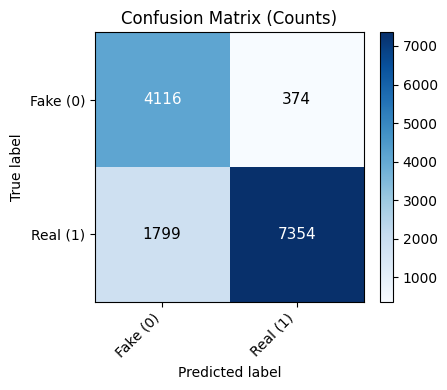

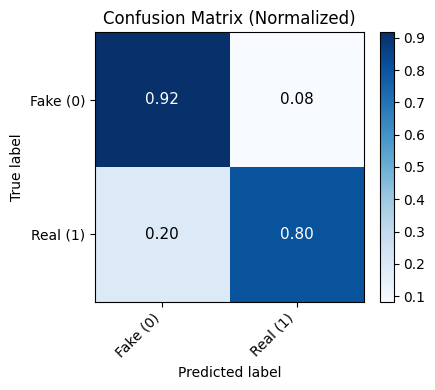

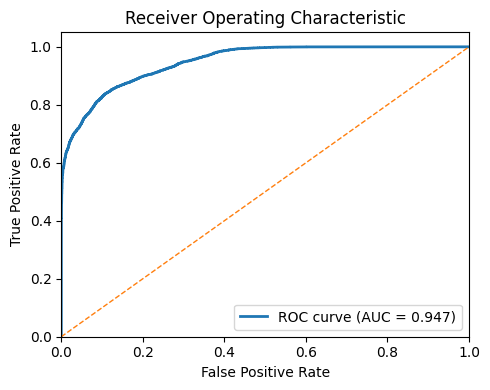

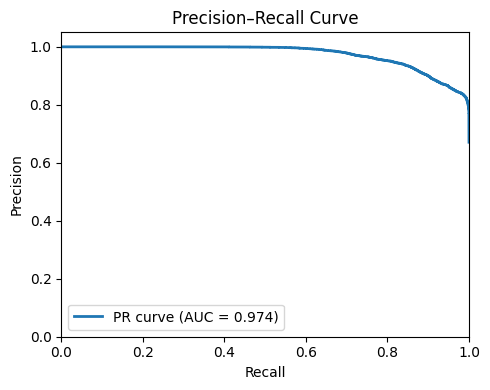

In [4]:
import os, re, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt
import keras # Import keras directly

# ---- paths ----
BASE = "/content/drive/MyDrive"
MODEL_PATH = f"{BASE}/news_models_tuned/bilstm_tuned_best.keras"  # adjust if different
SPLIT_DIR  = f"{BASE}/news_splits_tuned"                          # where train/val/test.csv live

# ---- re-declare the EXACT custom standardize used in training ----
@keras.saving.register_keras_serializable()   # make it serializable in Keras 3
def custom_standardize(x):
    x = tf.strings.lower(x)
    x = tf.strings.regex_replace(x, r"<[^>]+>", " ")
    x = tf.strings.regex_replace(x, r"\s+", " ")
    return x

# 1) Load tuned model (has TextVectorization inside)
# Provide the custom function via custom_objects so deserialization succeeds
model = load_model(MODEL_PATH, custom_objects={"custom_standardize": custom_standardize})
model.summary()

# 2) Load exact test set
df_test = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))
X_test_texts = df_test["text_full"].astype(str).tolist()
y_test = df_test["label"].astype(int).values

# 3) Predict with raw strings (no tokenizer needed)
#    Use a tf.data pipeline for memory/speed if large:
test_ds_raw = tf.data.Dataset.from_tensor_slices(X_test_texts).batch(128)
probs = model.predict(test_ds_raw, verbose=0).ravel()
y_pred = (probs >= 0.5).astype(int)   # default threshold; tune if you wish

# 4) Metrics
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec_macro  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro   = f1_score(y_test, y_pred, average="macro", zero_division=0)
prec_w     = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec_w      = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_w       = f1_score(y_test, y_pred, average="weighted", zero_division=0)
auc_roc    = roc_auc_score(y_test, probs)

print(f"Accuracy          : {acc:.4f}")
print(f"Precision (macro) : {prec_macro:.4f}   | Precision (weighted): {prec_w:.4f}")
print(f"Recall (macro)    : {rec_macro:.4f}    | Recall (weighted)   : {rec_w:.4f}")
print(f"F1-score (macro)  : {f1_macro:.4f}     | F1-score (weighted) : {f1_w:.4f}")
print(f"ROC-AUC           : {auc_roc:.4f}\n")

print("Classification report:\n",
      classification_report(y_test, y_pred, digits=4, target_names=["Fake(0)","Real(1)"]))

# 5) Colored Confusion Matrices (counts + normalized)
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
cm_norm = confusion_matrix(y_test, y_pred, labels=[0,1], normalize='true')

def plot_cm(mat, title, fmt=".2f", ticklabels=("Fake (0)","Real (1)")):
    plt.figure(figsize=(5,4))
    im = plt.imshow(mat, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(ticklabels))
    plt.xticks(tick_marks, ticklabels, rotation=45, ha="right")
    plt.yticks(tick_marks, ticklabels)
    thresh = mat.max() / 2.0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = f"{val}" if fmt == "d" else f"{val:{fmt}}"
            plt.text(j, i, txt, ha="center", va="center",
                     color="white" if val > thresh else "black", fontsize=11)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

# Counts
plot_cm(cm, "Confusion Matrix (Counts)", fmt="d")

# Normalized (per true class)
plot_cm(cm_norm, "Confusion Matrix (Normalized)", fmt=".2f")

# 6) ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 7) Precision–Recall Curve
prec, rec, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(rec, prec)

plt.figure(figsize=(5,4))
plt.plot(rec, prec, linewidth=2, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()